In [1]:
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

In [15]:
class MinHeap:
    def __init__(self):
        self.heap = [0]
        self.size = 0

    def arrange(self, k):
        while k // 2 > 0:
            if self.heap[k] < self.heap[k // 2]:
                self.heap[k], self.heap[k // 2] = self.heap[k // 2], self.heap[k]
            k //= 2

    def insert(self, item):
        self.heap.append(item)
        self.size += 1
        self.arrange(self.size)

    def sink(self, k):
        while k * 2 <= self.size:
            mc = self.minchild(k)
            if self.heap[k] > self.heap[mc]:
                self.heap[k], self.heap[mc] = self.heap[mc], self.heap[k]
            k = mc

    def minchild(self, k):
        if k * 2 + 1 > self.size:
            return k * 2
        elif self.heap[k * 2] < self.heap[k * 2 + 1]:
            return k * 2
        else:
            return k * 2 + 1

    def delete_at_root(self):
        item = self.heap[1]
        self.heap[1] = self.heap[self.size]
        self.size -= 1
        self.heap.pop()
        self.sink(1)
        return item

    def delete_at_location(self, location):
        item = self.heap[location]
        self.heap[location] = self.heap[self.size]
        self.size -= 1
        self.heap.pop()
        self.sink(location)
        return item

    def to_nx(self) -> nx.DiGraph:
        g = nx.DiGraph(data=None)

        for i in range(1, self.size + 1):
            g.add_node(i, data=self.heap[i])
            if 2 * i <= self.size:
                g.add_edge(i, 2 * i)
            if 2 * i + 1 <= self.size:
                g.add_edge(i, 2 * i + 1)

        return g

In [16]:
h = MinHeap()
for i in (4, 8, 7, 2, 9, 10, 5, 1, 3, 6):
    h.insert(i)
print(h.heap)

[0, 1, 2, 5, 3, 6, 10, 7, 8, 4, 9]


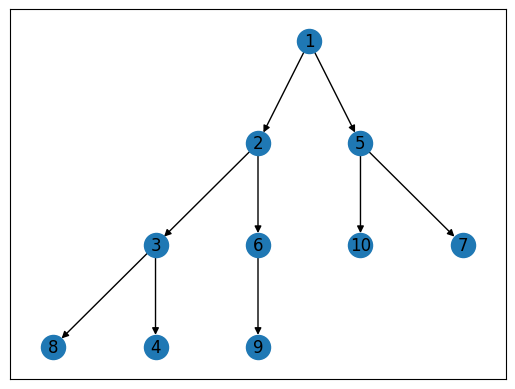

In [17]:
g = h.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

In [6]:
n = h.delete_at_root()
print(n)
print(h.heap)

1
[0, 2, 3, 5, 4, 6, 10, 7, 8, 9]


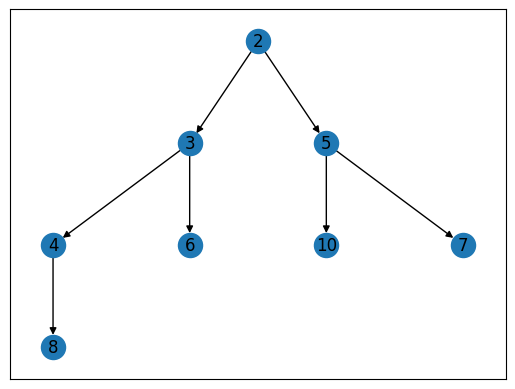

In [7]:
g = h.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

In [8]:
h = MinHeap()
for i in (4, 8, 7, 2, 9, 10, 5, 1, 3, 6):
    h.insert(i)
print(h.heap)

[0, 1, 2, 5, 3, 6, 10, 7, 8, 4, 9]


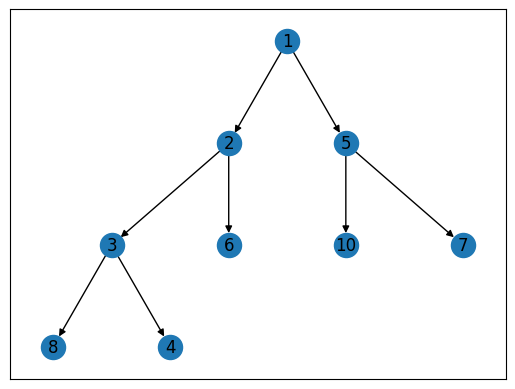

In [9]:
g = h.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

In [10]:
n = h.delete_at_location(2)
print(n)
print(h.heap)

2
[0, 1, 3, 5, 4, 6, 10, 7, 8, 9]


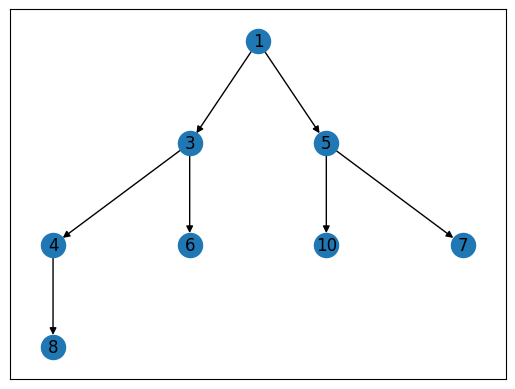

In [11]:
g = h.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

# Problem
Advanced Min-Heap Problem: Merge K Sorted Lists
Problem Statement

You are given an array of k linked-lists lists, each linked-list is sorted in ascending order. Merge all the linked-lists into one sorted linked-list and return it.

Input: lists = [[1,4,5],[1,3,4],[2,6]]

Output: [1,1,2,3,4,4,5,6]

Explanation: The linked-lists are:
[
  1->4->5,
  1->3->4,
  2->6
]
Merging them into one sorted list:
1->1->2->3->4->4->5->6

In [40]:
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next


def mergeKLists(lists):
    """
    :type lists: List[ListNode]
    :rtype: ListNode
    """
    # Your implementation here

In [21]:
import heapq


def mergeKLists(lists):
    # Create a min-heap
    min_heap = []

    # Push first node of each list into heap
    for i, node in enumerate(lists):
        if node:
            heapq.heappush(min_heap, (node.val, i, node))
            # i is used as tie-breaker for nodes with same value

    # Dummy head for result
    dummy = ListNode(0)
    current = dummy

    # Process heap
    while min_heap:
        val, idx, node = heapq.heappop(min_heap)
        current.next = ListNode(val)
        current = current.next

        # Move to next node in that list
        if node.next:
            heapq.heappush(min_heap, (node.next.val, idx, node.next))

    return dummy.next

In [41]:
# Helper: Convert list to linked list
def to_linked_list(arr):
    dummy = ListNode(0)
    current = dummy
    for val in arr:
        current.next = ListNode(val)
        current = current.next
    return dummy.next


# Helper: Convert linked list to list
def to_list(node):
    result = []
    while node:
        result.append(node.val)
        node = node.next
    return result

In [50]:
def mergeKLists(lists):
    # Create a min-heap
    min_heap = MinHeap()

    # Push first node of each list into heap
    for node in lists:
        print(to_list(node))

        while node is not None:
            print(f"{node.val=}")
            min_heap.insert(node.val)
            node = node.next

    # Dummy head for result
    dummy = ListNode(0)
    current = dummy

    # Process heap
    while min_heap.size > 0:
        val = min_heap.delete_at_root()
        current.next = ListNode(val)
        current = current.next

    return dummy.next

In [51]:
def test_merge_k_lists():
    # Test cases
    test_cases = [
        # (input lists, expected output)
        ([[1, 4, 5], [1, 3, 4], [2, 6]], [1, 1, 2, 3, 4, 4, 5, 6]),
        ([], []),
        ([[]], []),
        ([[1, 2, 3]], [1, 2, 3]),
        ([[1], [0]], [0, 1]),
        ([[-5, -3, 0], [-4, -2, 1]], [-5, -4, -3, -2, 0, 1]),
        ([[1, 2, 3], [4, 5, 6], [7, 8, 9]], [1, 2, 3, 4, 5, 6, 7, 8, 9]),
    ]

    for i, (input_lists, expected) in enumerate(test_cases):
        # Convert input to linked lists
        lists = [to_linked_list(lst) for lst in input_lists]

        # Merge
        result = mergeKLists(lists)

        # Convert back to list
        result_list = to_list(result)

        if result_list == expected:
            print(f"Test {i + 1} passed ✓")
        else:
            print(f"Test {i + 1} failed ✗")
            print(f"  Expected: {expected}")
            print(f"  Got: {result_list}")


test_merge_k_lists()

[1, 4, 5]
node.val=1
node.val=4
node.val=5
[1, 3, 4]
node.val=1
node.val=3
node.val=4
[2, 6]
node.val=2
node.val=6
Test 1 passed ✓
Test 2 passed ✓
[]
Test 3 passed ✓
[1, 2, 3]
node.val=1
node.val=2
node.val=3
Test 4 passed ✓
[1]
node.val=1
[0]
node.val=0
Test 5 passed ✓
[-5, -3, 0]
node.val=-5
node.val=-3
node.val=0
[-4, -2, 1]
node.val=-4
node.val=-2
node.val=1
Test 6 passed ✓
[1, 2, 3]
node.val=1
node.val=2
node.val=3
[4, 5, 6]
node.val=4
node.val=5
node.val=6
[7, 8, 9]
node.val=7
node.val=8
node.val=9
Test 7 passed ✓
